✅ Loaded 1237 rows from stock_data_features.csv
📊 Train: 989 rows | Test: 248 rows

  MODEL COMPARISON

📌 Logistic Regression
   Test Accuracy : 42.74%
   CV Accuracy   : 51.76% ± 4.13%

📌 Random Forest
   Test Accuracy : 43.15%
   CV Accuracy   : 49.04% ± 3.37%

📌 KNN
   Test Accuracy : 45.97%
   CV Accuracy   : 50.96% ± 3.28%

🏆 Best Model: KNN (45.97% accuracy)

📋 Classification Report:
              precision    recall  f1-score   support

    DOWN (0)       0.42      0.69      0.52       106
      UP (1)       0.55      0.29      0.38       142

    accuracy                           0.46       248
   macro avg       0.49      0.49      0.45       248
weighted avg       0.50      0.46      0.44       248

📊 Saved confusion_matrices.png


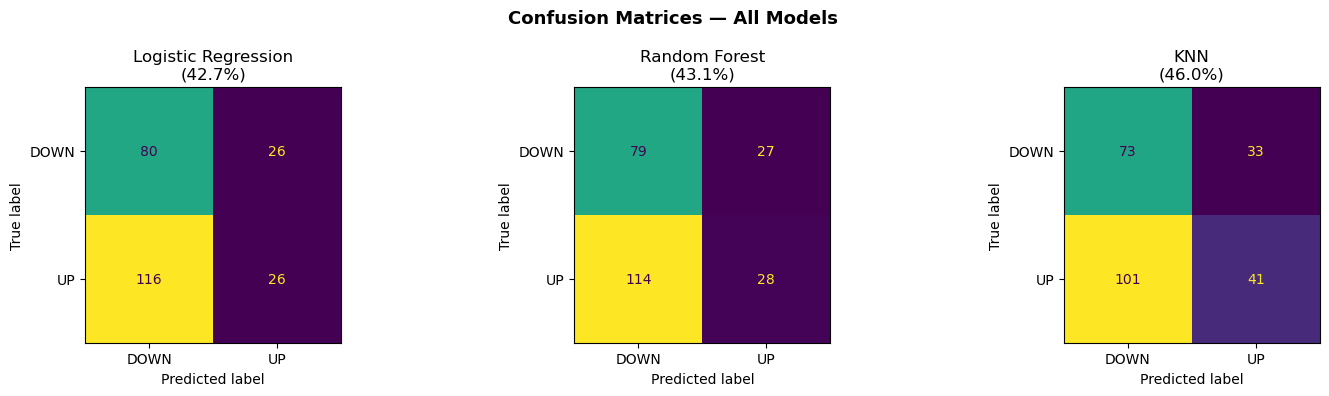


💾 Saved 'KNN' model + scaler to 'models/' folder
   → best_model.pkl
   → scaler.pkl
   → feature_cols.pkl

✅ All done! Run app.py next to launch the Streamlit app.


In [1]:
"""
Day 3 & 4: Model Training & Evaluation
Run AFTER data_prep.py has created stock_data_features.csv
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics         import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)


# ─── Config ───────────────────────────────────────────────────────────────────
FEATURE_COLS = [
    'Return', 'MA5', 'MA10', 'MA20',
    'MA5_above_MA20', 'Volume_Change',
    'Price_vs_MA20', 'RSI',
    'Volatility', 'HL_Range'
]
TARGET_COL = 'Target'
MODEL_DIR  = "models"
os.makedirs(MODEL_DIR, exist_ok=True)


def load_data(csv_path: str = "stock_data_features.csv"):
    """Load the feature CSV produced by data_prep.py."""
    if not os.path.exists(csv_path):
        raise FileNotFoundError(
            f"'{csv_path}' not found. Run data_prep.py first!"
        )
    df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
    print(f"✅ Loaded {len(df)} rows from {csv_path}")
    return df


def prepare_xy(df: pd.DataFrame):
    """Split into features (X) and target (y), then train/test split."""
    X = df[FEATURE_COLS]
    y = df[TARGET_COL]

    # Chronological split — IMPORTANT for stock data (no future leakage!)
    split = int(len(X) * 0.80)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]

    print(f"📊 Train: {len(X_train)} rows | Test: {len(X_test)} rows")
    return X_train, X_test, y_train, y_test


def scale_features(X_train, X_test):
    """
    StandardScaler: makes all features have mean=0 and std=1.
    Needed for Logistic Regression and KNN (not for Random Forest, but doesn't hurt).
    """
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)   # fit ONLY on train
    X_test_s  = scaler.transform(X_test)         # apply same scale to test
    return X_train_s, X_test_s, scaler


def train_and_compare(X_train, X_test, y_train, y_test):
    """Train 3 models and compare their performance."""
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
        "KNN":                 KNeighborsClassifier(n_neighbors=5),
    }

    results = {}
    print("\n" + "="*55)
    print("  MODEL COMPARISON")
    print("="*55)

    for name, model in models.items():
        model.fit(X_train, y_train)
        preds   = model.predict(X_test)
        acc     = accuracy_score(y_test, preds)

        # Cross-validation on training set (5-fold)
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

        results[name] = {
            "model":    model,
            "accuracy": acc,
            "cv_mean":  cv_scores.mean(),
            "cv_std":   cv_scores.std(),
            "preds":    preds,
        }
        print(f"\n📌 {name}")
        print(f"   Test Accuracy : {acc*100:.2f}%")
        print(f"   CV Accuracy   : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")

    return results


def evaluate_best(results: dict, y_test):
    """Pick the best model and show detailed report + confusion matrix."""
    best_name = max(results, key=lambda k: results[k]['accuracy'])
    best      = results[best_name]

    print(f"\n🏆 Best Model: {best_name} ({best['accuracy']*100:.2f}% accuracy)")
    print("\n📋 Classification Report:")
    print(classification_report(y_test, best['preds'], target_names=["DOWN (0)", "UP (1)"]))

    # Confusion Matrix
    fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4))
    for ax, (name, r) in zip(axes, results.items()):
        cm = confusion_matrix(y_test, r['preds'])
        ConfusionMatrixDisplay(cm, display_labels=["DOWN", "UP"]).plot(ax=ax, colorbar=False)
        ax.set_title(f"{name}\n({r['accuracy']*100:.1f}%)")

    plt.suptitle("Confusion Matrices — All Models", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig("confusion_matrices.png", dpi=120)
    print("📊 Saved confusion_matrices.png")
    plt.show()

    return best_name, best['model']


def plot_feature_importance(model, feature_names):
    """Show which features matter most (Random Forest only)."""
    if not hasattr(model, 'feature_importances_'):
        return
    importances = model.feature_importances_
    indices     = np.argsort(importances)[::-1]

    plt.figure(figsize=(10, 5))
    plt.bar(range(len(importances)), importances[indices], color='steelblue')
    plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45, ha='right')
    plt.title("Feature Importance (Random Forest)")
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=120)
    print("📊 Saved feature_importance.png")
    plt.show()


def save_model(model, scaler, model_name: str):
    """Save model + scaler to disk for use in the Streamlit app."""
    joblib.dump(model,  f"{MODEL_DIR}/best_model.pkl")
    joblib.dump(scaler, f"{MODEL_DIR}/scaler.pkl")
    joblib.dump(FEATURE_COLS, f"{MODEL_DIR}/feature_cols.pkl")
    print(f"\n💾 Saved '{model_name}' model + scaler to '{MODEL_DIR}/' folder")
    print("   → best_model.pkl")
    print("   → scaler.pkl")
    print("   → feature_cols.pkl")


# ─── Run ──────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    df = load_data("stock_data_features.csv")

    X_train, X_test, y_train, y_test = prepare_xy(df)
    X_train_s, X_test_s, scaler      = scale_features(X_train, X_test)

    results = train_and_compare(X_train_s, X_test_s, y_train, y_test)

    best_name, best_model = evaluate_best(results, y_test)

    # Feature importance (works for Random Forest)
    plot_feature_importance(best_model, FEATURE_COLS)

    # Save the best model
    save_model(best_model, scaler, best_name)

    print("\n✅ All done! Run app.py next to launch the Streamlit app.")
